In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load
df = pd.read_csv("../data/ecommerce.csv")
print(df.head())

  Customer_ID  Age  Gender       City Device_Type  Session_Duration  \
0      C00001   25    Male       Pune      Laptop                12   
1      C00002   45    Male  Bangalore      Mobile                11   
2      C00003   46  Female    Kolkata      Mobile                29   
3      C00004   31  Female  Bangalore      Mobile                17   
4      C00005   47    Male    Chennai      Mobile                22   

   Pages_Viewed Product_Category  Price  Discount  Purchase_History  \
0             5          Fashion   4016         5                 9   
1             5      Electronics  26390        10                 9   
2            14          Fashion   3859        20                 6   
3             3             Home   4317        25                 5   
4             6             Home   3075        30                 2   

   Time_Spent_on_Product Payment_Method  Cart_Value Purchased  
0                      4     Debit Card        3815        No  
1                 

C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


         Type  Accuracy
0  No Scaling     0.759
1     Scaling     0.782


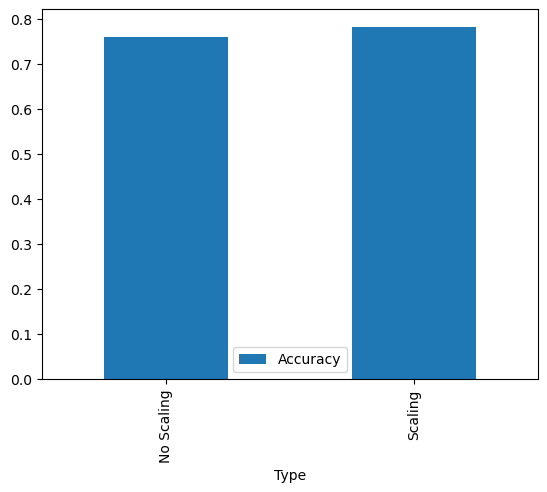

In [5]:
df.columns = df.columns.str.strip().str.lower()
# Convert target
df["purchased"] = df["purchased"].map({"Yes": 1, "No": 0})

# Drop ID column
df = df.drop(columns=["customer_id"], errors="ignore")
# Drop missing values
df = df.dropna()

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)
# Define features and target
y = df["purchased"]
X = df.drop(columns=["purchased"])

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

# Without scaling
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_ns, y_train_ns)
pred1 = model.predict(X_test_ns)

# With scaling (already scaled)
model.fit(X_train, y_train)
pred2 = model.predict(X_test)

results = pd.DataFrame({
    "Type": ["No Scaling", "Scaling"],
    "Accuracy": [
        accuracy_score(y_test_ns, pred1),
        accuracy_score(y_test, pred2)
    ]
})

print(results)

results.to_csv("rq3_table.csv", index=False)

results.set_index("Type").plot(kind="bar")
plt.savefig("rq3_figure.pdf")
plt.show()